# 06. 대화 요약 (Conversation Summary)

> 메시지를 그냥 삭제하면 맥락도 함께 사라져요. **증분 요약**을 노드로 끼워 넣어 토큰 비용은 줄이고 맥락은 유지하는 패턴을 구현해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. 긴 대화에서 발생하는 컨텍스트 윈도우 문제를 이해하고 설명할 수 있어요
2. `MessagesState`를 확장하여 `summary` 필드를 가진 커스텀 상태를 정의할 수 있어요
3. 대화 길이를 기준으로 요약 노드로 라우팅하는 조건 함수를 작성할 수 있어요
4. `RemoveMessage`로 오래된 메시지를 삭제하면서 증분 요약(incremental summary)을 구현할 수 있어요

## 사전 지식

- `05-DeleteMessages.ipynb` — RemoveMessage, 히스토리 트리밍
- `04-Durable-Execution.ipynb` — MemorySaver, 체크포인터
- `StateGraph`의 노드·엣지·조건부 분기 기초

## 왜 대화 요약이 필요한가요?

대화를 지속하면 메시지가 계속 쌓입니다. 하지만 LLM은 처리할 수 있는 토큰 수가 한정되어 있어요.

앞서 `05-DeleteMessages`에서 오래된 메시지를 **단순 삭제**하는 방법을 배웠어요. 하지만 삭제하면 맥락을 잃어버려요. 마치 회의 녹음을 전부 지워버리는 것과 같죠. **대화 요약**은 녹음을 지우되, 핵심 내용을 회의록으로 남기는 것과 같아요.

| 방법 | 장점 | 단점 |
|------|------|------|
| 단순 삭제 (05번 노트북) | 구현 간단, 즉시 효과 | 맥락 유실, 이전 정보 참조 불가 |
| **대화 요약** (이번 노트북) | 맥락 보존, 토큰 절약 | 요약 비용 발생, 세부 정보 손실 가능 |

| 문제 | 영향 |
|------|------|
| 컨텍스트 윈도우 초과 | 오류 발생, 오래된 메시지 잘림 |
| 토큰 비용 증가 | 긴 대화일수록 비용이 급격히 증가 |
| 응답 지연 | 처리할 토큰이 많을수록 응답이 느려짐 |

**해결책**: 대화 기록을 주기적으로 요약하고, 오래된 메시지는 삭제해요. 요약본은 시스템 메시지로 주입하여 맥락을 유지해요.

> 🔑 **핵심 개념**: 대화 요약 패턴은 "모든 메시지를 보존" 대신 "맥락을 유지하면서 오래된 메시지를 압축"하는 전략이에요. 마치 회의록을 요약해 두고 원본 속기를 버리는 것과 같아요.

### 전체 아키텍처

```mermaid
flowchart TD
    A([START]) --> B[conversation<br/>대화 노드]
    B --> C{should_continue<br/>메시지 6개 초과?}
    C -- "아니오 (6개 이하)" --> D([END])
    C -- "예 (6개 초과)" --> E[summarize_conversation<br/>요약 노드]
    E --> D

    style A fill:#d4edda,stroke:#28a745,color:#155724
    style D fill:#d4edda,stroke:#28a745,color:#155724
    style B fill:#cce5ff,stroke:#007bff,color:#004085
    style C fill:#fff3cd,stroke:#ffc107,color:#856404
    style E fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

### 상태 구조

| 필드 | 타입 | 설명 |
|------|------|------|
| `messages` | `list` | 대화 메시지 목록 (add_messages reducer) |
| `summary` | `str` | 이전 대화의 요약본 (초기값: 빈 문자열) |

> 💡 **실무 팁**: 메시지 수 외에도 전체 토큰 수를 기준으로 요약을 트리거할 수 있어요. 토큰 기준은 더 정밀하지만 구현이 복잡해져요. 학습 단계에서는 메시지 수 기준이 직관적이에요.

## 1. 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# OPENAI_API_KEY 등 API 키를 .env 파일에서 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택)
# ---------------------------------------------------
# 실행 흐름을 LangSmith에서 시각적으로 확인할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-04-ConversationSummary"

## 2. 커스텀 State 정의

`MessagesState`를 상속받아 `summary` 필드를 추가해요.
기본 `MessagesState`에는 `messages`만 있지만, 우리는 요약본을 별도로 저장할 공간이 필요해요.

> 🔑 **핵심 개념**: `MessagesState`를 상속하면 `messages` 필드와 `add_messages` reducer를 그대로 물려받아요. 추가 필드는 일반 Python 타입 힌트로 선언하면 돼요.

> ⚠️ **자주 하는 실수**: `summary` 필드의 기본값을 지정하지 않으면 첫 실행 시 `state.get("summary", "")` 없이 직접 접근할 때 `KeyError`가 발생해요. `state.get()`으로 안전하게 읽는 습관을 들이세요.

In [ ]:
# ---------------------------------------------------
# 의존성 import
# ---------------------------------------------------
# Annotated: 타입 힌트에 메타데이터(reducer)를 붙여요
# Literal: 반환 타입을 특정 문자열 값으로 제한해요
from typing import Literal, Annotated

# init_chat_model: V1 방식의 모델 초기화 함수예요
from langchain.chat_models import init_chat_model

# 메시지 타입들 - 역할에 따라 다른 클래스를 사용해요
from langchain.messages import SystemMessage, RemoveMessage, HumanMessage

# MemorySaver: 인메모리 체크포인터 (프로덕션에서는 PostgresSaver 사용)
from langgraph.checkpoint.memory import MemorySaver

# MessagesState: messages 필드가 기본 포함된 상태 베이스 클래스
# StateGraph, START, END: 그래프 구성 핵심 요소
from langgraph.graph import MessagesState, StateGraph, START, END

# add_messages: 메시지를 덮어쓰지 않고 누적하는 reducer
from langgraph.graph.message import add_messages

In [4]:
# ---------------------------------------------------
# 커스텀 State 클래스 정의
# ---------------------------------------------------
# MessagesState를 상속받아 summary 필드를 추가해요
class State(MessagesState):
    # messages는 MessagesState에서 상속 (add_messages reducer 포함)
    messages: Annotated[list, add_messages]
    # summary: 이전 대화의 요약본을 저장해요 (없을 때는 빈 문자열)
    summary: str


# ---------------------------------------------------
# LLM 모델 초기화
# ---------------------------------------------------
# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 옵션:
#   - "openai:gpt-4o"          → 더 정확한 요약
#   - "anthropic:claude-sonnet-4-5" → Anthropic 사용 시
#   - "google_genai:gemini-2.0-flash" → Google Gemini 사용 시
llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

# ---------------------------------------------------
# 메모리 체크포인터 초기화
# ---------------------------------------------------
# MemorySaver: 서버 재시작 시 상태가 사라지는 인메모리 저장소
# 프로덕션에서는 PostgresSaver 또는 SqliteSaver를 사용해요
memory = MemorySaver()

print("상태 필드:", State.__annotations__)
print("모델 초기화 완료:", llm.model_name)

상태 필드: {'messages': typing.Annotated[list, <function _add_messages_wrapper.<locals>._add_messages at 0x113913690>], 'summary': <class 'str'>}
모델 초기화 완료: gpt-4o-mini


## 3. 노드 함수 정의

그래프에는 두 개의 노드가 있어요:
1. **`conversation`** — 사용자 메시지에 응답하는 일반 대화 노드
2. **`summarize_conversation`** — 메시지를 요약하고 오래된 메시지를 삭제하는 노드

### 3-1. conversation 노드 (ask_llm)

In [5]:
# ---------------------------------------------------
# conversation 노드: LLM 호출
# ---------------------------------------------------
# 핵심 로직:
#   1. 이전 요약(summary)이 있으면 SystemMessage로 주입
#   2. 요약 + 현재 메시지를 합쳐서 LLM에 전달
#   3. 요약이 없으면 현재 메시지만 사용
def ask_llm(state: State):
    # 이전 요약 정보 가져오기 (없으면 빈 문자열)
    summary = state.get("summary", "")

    if summary:
        # 요약이 있으면 시스템 메시지로 맥락 주입
        system_content = f"Summary of conversation earlier: {summary}"
        # 시스템 메시지를 앞에, 현재 대화를 뒤에 배치
        messages = [SystemMessage(content=system_content)] + state["messages"]
    else:
        # 요약이 없으면 현재 메시지만 사용
        messages = state["messages"]

    # LLM 호출 후 응답 반환
    response = llm.invoke(messages)
    return {"messages": [response]}

### 3-2. should_continue 조건 함수

대화 흐름을 결정하는 라우터 함수예요. 메시지 수를 검사하여 요약이 필요한지 판단해요.

> 🎯 **강의 포인트**: 임계값 `6`의 의미 — 한 번의 대화 턴은 HumanMessage + AIMessage = 2개예요. 6개는 3턴에 해당해요. 이 값을 조정하면 요약 빈도를 조절할 수 있어요.

In [6]:
# ---------------------------------------------------
# 조건 함수: 요약 필요 여부 판단
# ---------------------------------------------------
# 반환 타입: Literal["summarize_conversation", END]
# → 두 가지 경로 중 하나만 반환할 수 있음을 타입 시스템에 알려줘요
def should_continue(state: State) -> Literal["summarize_conversation", END]:
    messages = state["messages"]

    # 메시지가 6개를 초과하면 요약 필요
    # 예: 4턴 대화 = 8개 메시지 → 요약 트리거
    if len(messages) > 6:
        return "summarize_conversation"

    # 6개 이하면 바로 종료
    return END

### 3-3. summarize_conversation 노드

이 노드는 두 가지 역할을 동시에 수행해요:
1. **증분 요약 생성** -- 기존 요약이 있으면 확장하고, 없으면 새로 생성
2. **메시지 정리** -- 마지막 2개를 제외한 모든 메시지를 `RemoveMessage`로 삭제

### 신규 요약 vs 증분 요약

```mermaid
flowchart TD
    A{이전 요약이 있나요?} -->|없음| B["전체 대화를 요약<br/>(신규 생성)"]
    A -->|있음| C["기존 요약 + 새 메시지<br/>(증분 확장)"]
    B --> D["마지막 2개 메시지 제외<br/>나머지 RemoveMessage 삭제"]
    C --> D
    D --> E["summary 필드 업데이트"]
    
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#d4edda,stroke:#28a745,color:#155724
    
    class A decision
    class B,C,D process
    class E output
```

> 🔑 **핵심 개념**: **증분 요약(incremental summary)**이란 매번 전체 대화를 요약하는 대신, 기존 요약에 새 내용만 추가하는 방식이에요. 이렇게 하면 요약 자체의 토큰 비용도 절약돼요.

> 💡 **실무 팁**: 마지막 2개 메시지(최신 턴)를 보존하는 이유는, 바로 직전 대화 맥락이 없으면 LLM이 갑자기 주제가 바뀐 것처럼 느낄 수 있기 때문이에요.

> ⚠️ **자주 하는 실수**: 증분 요약을 무한히 반복하면 요약 자체가 점점 길어질 수 있어요. 프로덕션에서는 요약 문자열의 **최대 길이도 제한**하는 것이 좋아요.

In [7]:
# ---------------------------------------------------
# summarize_conversation 노드: 요약 + 메시지 정리
# ---------------------------------------------------
# 처리 순서:
#   1. 기존 요약 확인
#   2. 요약 프롬프트 생성 (신규 vs 확장)
#   3. LLM으로 요약 생성
#   4. 오래된 메시지 삭제 (마지막 2개 제외)
#   5. 새 요약 + 삭제 명령 반환
def summarize_conversation(state: State):
    # 이전 요약 가져오기
    summary = state.get("summary", "")

    if summary:
        # 기존 요약이 있으면 "확장" 프롬프트 사용
        # 이전 요약 내용을 컨텍스트로 제공하고 새 메시지를 반영하도록 요청
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above in Korean:"
        )
    else:
        # 요약이 없으면 "신규 생성" 프롬프트 사용
        summary_message = "Create a summary of the conversation above in Korean:"

    # 현재 메시지 전체 + 요약 요청 메시지를 LLM에 전달
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = llm.invoke(messages)

    # ---------------------------------------------------
    # 오래된 메시지 삭제
    # ---------------------------------------------------
    # state["messages"][:-2] = 마지막 2개를 제외한 나머지 메시지
    # RemoveMessage(id=m.id): 해당 id를 가진 메시지를 상태에서 제거해요
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]

    # summary: 새 요약본으로 업데이트
    # messages: 삭제 명령 목록 (add_messages reducer가 처리)
    return {"summary": response.content, "messages": delete_messages}

## 4. 그래프 조립 및 컴파일

In [8]:
# ---------------------------------------------------
# StateGraph 생성 및 노드 등록
# ---------------------------------------------------
# StateGraph(State): 우리가 정의한 커스텀 State 클래스를 사용해요
workflow = StateGraph(State)

# 노드 추가
# 첫 번째 인자: 노드 이름 (엣지에서 참조하는 이름)
# 두 번째 인자: 실행할 함수
workflow.add_node("conversation", ask_llm)         # 대화 노드
workflow.add_node("summarize_conversation", summarize_conversation)  # 요약 노드

# ---------------------------------------------------
# 엣지 연결
# ---------------------------------------------------
# 시작점 → conversation 노드
workflow.add_edge(START, "conversation")

# conversation 노드 → 조건부 분기
# should_continue()의 반환값에 따라 경로 결정
workflow.add_conditional_edges("conversation", should_continue)

# summarize_conversation 완료 → 종료
workflow.add_edge("summarize_conversation", END)

# ---------------------------------------------------
# 그래프 컴파일
# ---------------------------------------------------
# checkpointer=memory: thread_id별로 상태를 자동 저장/복원해요
app = workflow.compile(checkpointer=memory)

# 그래프 컴파일 완료!

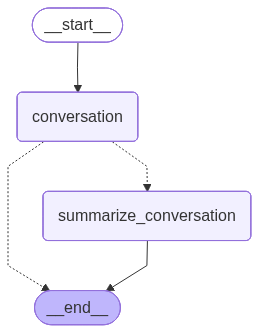

In [9]:
# 그래프 흐름: START → conversation → {should_continue} → summarize_conversation 또는 END
# conversation 노드: LLM을 호출해 응답을 생성해요 (요약이 있으면 SystemMessage로 주입)
# 조건부 엣지: 메시지 6개 초과 시 summarize_conversation으로, 이하면 END로 분기해요
# summarize_conversation 노드: 대화를 요약하고 마지막 2개 제외 메시지를 삭제해요
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 5. 그래프 실행 테스트

여러 메시지를 순서대로 보내면서 요약이 언제 트리거되는지 관찰해볼게요.

> 🎯 **강의 포인트**: `thread_id`를 동일하게 유지하면 MemorySaver가 이전 상태를 불러와 대화를 이어가요. `thread_id`를 바꾸면 새 대화 세션이 시작돼요.

### 5-1. 스트리밍 헬퍼 함수 정의

In [10]:
# ---------------------------------------------------
# 그래프 실행 결과를 스트리밍으로 출력하는 헬퍼 함수
# ---------------------------------------------------
# 그래프 스트리밍 출력을 직접 구현한 버전이에요
def stream_graph(app, inputs, config):
    """그래프를 스트리밍으로 실행하고 노드별 출력을 표시해요."""
    for chunk in app.stream(inputs, config, stream_mode="updates"):
        for node_name, node_output in chunk.items():
            print(f"\n{'='*50}")
            print(f"노드: [{node_name}]")
            # --------------------------------------------------

            # messages가 있으면 각 메시지 출력
            if "messages" in node_output:
                for msg in node_output["messages"]:
                    # RemoveMessage는 건너뜀 (삭제 명령은 출력할 필요 없음)
                    if hasattr(msg, "content") and not isinstance(msg, RemoveMessage):
                        msg.pretty_print()

            # summary가 있으면 출력
            if "summary" in node_output:
                print(f"[요약 생성됨]\n{node_output['summary']}")

### 5-2. 초기 대화 (요약 미발생 구간)

In [ ]:
# ---------------------------------------------------
# 스레드 설정
# ---------------------------------------------------
# thread_id: 대화 세션을 구분하는 식별자
# 같은 thread_id를 사용하면 이전 대화 내용이 유지돼요
config = {"configurable": {"thread_id": "summary-demo-1"}}


# 첫 번째 메시지: 자기소개
# [1번째 메시지]
stream_graph(
    app,
    inputs={"messages": [HumanMessage(content="안녕하세요! 저는 LangGraph를 공부하는 민준이에요.")]},
    config=config,
)


노드: [conversation]
================================== Ai Message ==================================

안녕하세요, 민준님! LangGraph에 대해 공부하고 계시다니 멋지네요. LangGraph에 대해 궁금한 점이나 도움이 필요한 부분이 있으면 언제든지 말씀해 주세요!


In [12]:
# 두 번째 메시지: 이름 확인
# [2번째 메시지]
stream_graph(
    app,
    inputs={"messages": [HumanMessage(content="제 이름이 기억나세요?")]},
    config=config,
)


노드: [conversation]
================================== Ai Message ==================================

네, 민준님이라고 말씀하셨죠! 어떻게 도와드릴까요?


In [13]:
# 세 번째 메시지: 추가 정보
# [3번째 메시지]
stream_graph(
    app,
    inputs={"messages": [HumanMessage(content="저는 백엔드 개발자로 일하고 있어요. AI 관련 프로젝트를 진행 중이에요.")]},
    config=config,
)


노드: [conversation]
================================== Ai Message ==================================

백엔드 개발자로 일하시면서 AI 관련 프로젝트를 진행 중이시군요! 정말 흥미로운 분야입니다. 어떤 종류의 AI 프로젝트를 하고 계신가요? 또는 특정한 기술이나 도구에 대해 궁금한 점이 있으신가요?


### 5-3. 요약 전 상태 확인

3턴(6개 메시지)이 쌓인 현재 상태를 확인해봐요. 아직 요약은 발생하지 않았어요.

In [14]:
# ---------------------------------------------------
# 현재 그래프 상태 조회
# ---------------------------------------------------
# app.get_state(config): 해당 thread_id의 현재 상태를 가져와요
values = app.get_state(config).values

# 메시지 수와 요약 여부 확인
print(f"현재 메시지 수: {len(values['messages'])}개")
print(f"요약 존재 여부: {'있음' if values.get('summary') else '없음 (아직 요약 전)'}")
# --- 현재 메시지 목록 ---
for i, msg in enumerate(values["messages"], 1):
    print(f"{i}. [{msg.type}] {msg.content[:50]}..." if len(msg.content) > 50 else f"{i}. [{msg.type}] {msg.content}")

현재 메시지 수: 6개
요약 존재 여부: 없음 (아직 요약 전)
1. [human] 안녕하세요! 저는 LangGraph를 공부하는 민준이에요.
2. [ai] 안녕하세요, 민준님! LangGraph에 대해 공부하고 계시다니 멋지네요. LangGrap...
3. [human] 제 이름이 기억나세요?
4. [ai] 네, 민준님이라고 말씀하셨죠! 어떻게 도와드릴까요?
5. [human] 저는 백엔드 개발자로 일하고 있어요. AI 관련 프로젝트를 진행 중이에요.
6. [ai] 백엔드 개발자로 일하시면서 AI 관련 프로젝트를 진행 중이시군요! 정말 흥미로운 분야입니다...


### 5-4. 요약 트리거 (7번째 메시지)

4번째 메시지를 보내면 메시지가 7개가 되어 `should_continue`가 `summarize_conversation`을 선택해요.

In [15]:
# ---------------------------------------------------
# 네 번째 메시지: 요약 트리거
# ---------------------------------------------------
# 이 메시지 이후 메시지 수가 7개가 되어 요약이 발동해요
# (3턴 기존 6개 + 이번 HumanMessage 1개 = 7개 > 6개)
# [4번째 메시지 - 요약 트리거 예상]
stream_graph(
    app,
    inputs={"messages": [HumanMessage(content="LangGraph에서 StateGraph와 Functional API의 차이점이 궁금해요.")]},
    config=config,
)


노드: [conversation]
================================== Ai Message ==================================

LangGraph에서 **StateGraph**와 **Functional API**는 각각 다른 방식으로 그래프를 구성하고 다루는 방법을 제공합니다. 두 가지의 주요 차이점은 다음과 같습니다:

### 1. StateGraph
- **상태 기반**: StateGraph는 상태(state)와 상태 간의 전이(transition)를 중심으로 구성됩니다. 각 노드는 특정 상태를 나타내며, 노드 간의 연결은 상태 전이를 나타냅니다.
- **상태 관리**: 상태를 명시적으로 관리할 수 있어, 복잡한 상태 전이 로직을 구현하는 데 유리합니다. 예를 들어, 특정 조건에 따라 상태가 변경되는 경우를 쉽게 처리할 수 있습니다.
- **시각화**: 상태 전이를 시각적으로 표현하기 용이하여, 상태 흐름을 이해하고 디버깅하는 데 도움이 됩니다.

### 2. Functional API
- **함수 기반**: Functional API는 함수형 프로그래밍 패러다임을 따릅니다. 즉, 데이터 흐름과 변환을 함수로 표현합니다.
- **유연성**: 더 많은 유연성을 제공하며, 복잡한 데이터 처리 로직을 함수 조합을 통해 쉽게 구현할 수 있습니다. 다양한 함수형 기법을 활용하여 코드를 작성할 수 있습니다.
- **모듈화**: 코드의 모듈화가 용이하여, 재사용성과 유지보수성이 높습니다.

### 요약
- **StateGraph**는 상태 전이에 중점을 두고, 상태 관리가 필요한 경우에 유리합니다.
- **Functional API**는 함수형 프로그래밍을 통해 유연하고 모듈화된 접근 방식을 제공합니다.

어떤 방식이 더 적합할지는 프로젝트의 요구사항과 구조에 따라 다를 수 있습니다. 추가적인 질문이 있으시면 언제든지 말씀해 주세요!

노드: [summarize_conversation]
[요약 생성됨]
민준님은 백엔

### 5-5. 요약 후 상태 확인

요약이 완료된 후 상태를 확인해봐요. `summary` 필드에 요약본이 저장되고, `messages`에는 마지막 2개 메시지만 남아있어요.

In [16]:
# ---------------------------------------------------
# 요약 후 상태 조회
# ---------------------------------------------------
values = app.get_state(config).values

print(f"현재 메시지 수: {len(values['messages'])}개 (마지막 2개만 보존됨)")
# --- 남은 메시지 ---
for i, msg in enumerate(values["messages"], 1):
    print(f"{i}. [{msg.type}] {msg.content[:80]}..." if len(msg.content) > 80 else f"{i}. [{msg.type}] {msg.content}")

# --- 생성된 요약 ---
print(values.get("summary", "(요약 없음)"))

현재 메시지 수: 2개 (마지막 2개만 보존됨)
1. [human] LangGraph에서 StateGraph와 Functional API의 차이점이 궁금해요.
2. [ai] LangGraph에서 **StateGraph**와 **Functional API**는 각각 다른 방식으로 그래프를 구성하고 다루는 방법을 제공합...
민준님은 백엔드 개발자로 일하고 있으며 AI 관련 프로젝트를 진행 중이라고 말씀하셨습니다. LangGraph에서 **StateGraph**와 **Functional API**의 차이점에 대해 궁금해하셨고, 이에 대해 설명드렸습니다. 

- **StateGraph**는 상태와 상태 간의 전이에 중점을 두며, 상태 관리와 시각화에 유리합니다.
- **Functional API**는 함수형 프로그래밍을 기반으로 하여 유연성과 모듈화를 제공합니다.

어떤 방식이 더 적합할지는 프로젝트의 요구사항에 따라 다를 수 있다고 말씀드렸습니다. 추가 질문이 있으면 언제든지 도와드리겠다고 전했습니다.


### 5-6. 요약 기반 맥락 유지 확인

메시지 목록에는 2개밖에 없지만, 요약이 `SystemMessage`로 주입되어 이전 대화 내용을 기억하는지 확인해볼게요.

> 🎯 **강의 포인트**: 이것이 대화 요약 패턴의 핵심이에요. 실제 메시지 수는 줄었지만 LLM이 "이전에 민준이라고 소개했고, 백엔드 개발자"라는 정보를 요약을 통해 알고 있어요.

In [17]:
# ---------------------------------------------------
# 요약 기반 장기 기억 확인
# ---------------------------------------------------
# 메시지 목록에는 없는 정보지만 요약에는 있어요
# → LLM이 요약을 통해 이전 정보를 기억하는지 테스트
# [이름 기억 테스트]
stream_graph(
    app,
    inputs={"messages": [HumanMessage(content="제 이름이 뭔지 기억하세요?")]},
    config=config,
)


노드: [conversation]
================================== Ai Message ==================================

네, 민준님이라고 말씀하셨습니다. 추가로 궁금한 점이나 도움이 필요하신 부분이 있으면 언제든지 말씀해 주세요!


In [18]:
# 직업 정보 기억 테스트
# [직업 기억 테스트]
stream_graph(
    app,
    inputs={"messages": [HumanMessage(content="제 직업이 무엇인지도 기억하시나요?")]},
    config=config,
)


노드: [conversation]
================================== Ai Message ==================================

네, 민준님은 백엔드 개발자로 일하고 계신다고 말씀하셨습니다. AI 관련 프로젝트도 진행 중이라고 하셨죠. 추가로 궁금한 점이나 도움이 필요하신 부분이 있으면 언제든지 말씀해 주세요!


## 6. 증분 요약 동작 확인

대화가 더 길어지면 두 번째 요약이 생성될 때 기존 요약을 확장하는 증분 방식이 사용돼요.
새 대화를 시작하여 확인해봐요.

> ⚠️ **자주 하는 실수**: 증분 요약에서 이전 요약이 무한히 커질 수 있어요. 실제 프로덕션에서는 요약 자체의 최대 길이도 제한해야 해요.

In [19]:
# ---------------------------------------------------
# 증분 요약 테스트용 새 스레드
# ---------------------------------------------------
# thread_id를 바꿔서 새로운 대화 세션을 시작해요
config2 = {"configurable": {"thread_id": "incremental-summary-test"}}

# 첫 번째 요약을 유발할 만큼 대화 진행
test_messages = [
    "안녕하세요! 저는 데이터 과학자 지수예요.",
    "주로 Python으로 머신러닝 모델을 개발해요.",
    "요즘은 LLM 파인튜닝 프로젝트를 진행 중이에요.",
    "이 프로젝트에서 LangGraph를 사용하려고 해요.",  # 7번째 메시지 → 1차 요약 트리거
]

for i, msg_content in enumerate(test_messages, 1):
    print(f"\n[{i}번째 메시지 전송 중...]")
    stream_graph(
        app,
        inputs={"messages": [HumanMessage(content=msg_content)]},
        config=config2,
    )


[1번째 메시지 전송 중...]

노드: [conversation]
================================== Ai Message ==================================

안녕하세요, 지수님! 데이터 과학에 대해 이야기 나누고 싶으신가요? 궁금한 점이나 논의하고 싶은 주제가 있다면 말씀해 주세요!

[2번째 메시지 전송 중...]

노드: [conversation]
================================== Ai Message ==================================

멋지네요! Python은 머신러닝에 매우 적합한 언어죠. 주로 어떤 라이브러리를 사용하시나요? 예를 들어, scikit-learn, TensorFlow, PyTorch 등 다양한 선택지가 있는데, 특정 프로젝트나 관심 있는 분야가 있으신가요?

[3번째 메시지 전송 중...]

노드: [conversation]
================================== Ai Message ==================================

LLM(대형 언어 모델) 파인튜닝 프로젝트라니 흥미롭네요! 어떤 특정한 데이터셋이나 도메인에 대해 파인튜닝하고 계신가요? 또한, 어떤 프레임워크를 사용하고 있는지도 궁금합니다. LLM을 파인튜닝할 때의 도전 과제나 흥미로운 점이 있다면 공유해 주시면 좋을 것 같아요!

[4번째 메시지 전송 중...]

노드: [conversation]
================================== Ai Message ==================================

LangGraph는 LLM과 그래프 기반 데이터 구조를 결합하여 자연어 처리 작업을 수행하는 데 유용한 도구입니다. 그래프 구조를 활용하면 데이터 간의 관계를 더 잘 이해하고 모델의 성능을 향상시킬 수 있습니다. 

이 프로젝트에서 LangGraph를 사용하여 어떤 특정한 목표를 달성

In [20]:
# ---------------------------------------------------
# 1차 요약 결과 확인
# ---------------------------------------------------
values2 = app.get_state(config2).values
print(f"메시지 수: {len(values2['messages'])}개")
# [1차 요약]
print(values2.get("summary", "(없음)"))

메시지 수: 2개
지수님은 데이터 과학자로서 주로 Python을 사용하여 머신러닝 모델을 개발하고 있다고 하셨습니다. 현재는 LLM(대형 언어 모델) 파인튜닝 프로젝트를 진행 중이며, LangGraph라는 도구를 사용하려고 한다고 말씀하셨습니다. LangGraph는 LLM과 그래프 기반 데이터 구조를 결합하여 자연어 처리 작업을 수행하는 데 유용하다는 점을 언급했습니다. 대화 중에 프로젝트의 목표나 특정 태스크에 대한 질문도 나누었습니다.


In [21]:
# ---------------------------------------------------
# 추가 대화로 2차 요약 트리거
# ---------------------------------------------------
# 현재 메시지 2개 + 새 메시지 5개 = 7개 → 2차 요약 트리거
additional_messages = [
    "LangGraph의 StateGraph가 특히 유용해 보여요.",
    "조건부 엣지로 복잡한 워크플로우를 구현할 수 있겠네요.",
    "대화 요약 기능도 프로덕션에서 활용할 계획이에요.",  # 7번째 메시지 → 2차 요약 트리거
]

for i, msg_content in enumerate(additional_messages, 5):
    print(f"\n[{i}번째 메시지 전송 중...]")
    stream_graph(
        app,
        inputs={"messages": [HumanMessage(content=msg_content)]},
        config=config2,
    )


[5번째 메시지 전송 중...]

노드: [conversation]
================================== Ai Message ==================================

StateGraph는 LangGraph의 중요한 구성 요소로, 상태 기반의 그래프 구조를 통해 데이터 간의 관계를 효과적으로 모델링할 수 있게 해줍니다. 이를 통해 LLM이 특정 상태나 컨텍스트에 따라 더 적절한 응답을 생성할 수 있도록 도와줍니다.

StateGraph를 사용하면 다음과 같은 이점이 있을 수 있습니다:

1. **상태 관리**: 다양한 상태를 정의하고 이를 기반으로 모델의 응답을 조정할 수 있습니다. 예를 들어, 대화의 맥락이나 이전 질문에 따라 모델의 반응을 다르게 설정할 수 있습니다.

2. **관계 표현**: 데이터 간의 복잡한 관계를 그래프 형태로 표현함으로써, 모델이 더 깊이 있는 이해를 할 수 있도록 합니다.

3. **유연성**: 다양한 태스크에 맞게 StateGraph를 조정할 수 있어, 특정 요구사항에 맞는 맞춤형 솔루션을 개발할 수 있습니다.

이러한 기능들을 활용하여 프로젝트의 목표를 달성하는 데 큰 도움이 될 것입니다. StateGraph를 사용하여 어떤 특정한 기능이나 태스크를 구현할 계획이신가요?

[6번째 메시지 전송 중...]

노드: [conversation]
================================== Ai Message ==================================

맞습니다! 조건부 엣지를 사용하면 StateGraph 내에서 복잡한 워크플로우를 유연하게 구현할 수 있습니다. 조건부 엣지는 특정 조건이 충족될 때만 그래프의 특정 경로를 따라 이동할 수 있도록 하여, 다양한 상황에 맞는 동적인 흐름을 만들 수 있게 해줍니다.

이러한 기능을 활용하면 다음과 같은 이점이 있습니다:

1. **상황에 따른 반응**: 특정 조건에 따라 모델의 응답이나 행동을 조정할 수 

In [22]:
# ---------------------------------------------------
# 2차 요약 결과 확인 (증분 요약 검증)
# ---------------------------------------------------
values2_updated = app.get_state(config2).values
print(f"메시지 수: {len(values2_updated['messages'])}개")
# [2차 요약 - 1차 요약 내용이 확장되었어요]
print(values2_updated.get("summary", "(없음)"))

메시지 수: 2개
대화 요약을 확장하겠습니다:

지수님은 데이터 과학자로서 주로 Python을 사용하여 머신러닝 모델을 개발하고 있다고 하셨습니다. 현재는 LLM(대형 언어 모델) 파인튜닝 프로젝트를 진행 중이며, LangGraph라는 도구를 사용하려고 한다고 말씀하셨습니다. LangGraph는 LLM과 그래프 기반 데이터 구조를 결합하여 자연어 처리 작업을 수행하는 데 유용하다는 점을 언급했습니다. 대화 중에 프로젝트의 목표나 특정 태스크에 대한 질문도 나누었습니다.

특히, LangGraph의 StateGraph가 유용하다고 언급하셨으며, 조건부 엣지를 통해 복잡한 워크플로우를 구현할 수 있다는 점에 대해 논의했습니다. 또한, 대화 요약 기능을 프로덕션에서 활용할 계획이라고 하셨습니다. 이 기능은 고객 지원, 상담, 교육 등 다양한 분야에서 대화 내용을 간결하게 요약하여 중요한 정보를 빠르게 전달하는 데 도움이 될 것입니다. 대화의 맥락을 유지하고, 중요한 정보를 추출하며, 사용자 맞춤형 요약을 제공하는 방식으로 설계할 계획이라고 하셨습니다.


## 7. 실습: 요약 임계값 조절

아래 코드를 수정하여 요약 임계값을 바꿔보세요.

> 💡 **실무 팁**: 실제 서비스에서는 메시지 수 대신 토큰 수를 세는 것이 더 정확해요. `tiktoken` 라이브러리로 토큰을 계산하고, 임계값을 2000~3000 토큰으로 설정하는 것이 일반적이에요.

In [23]:
# ============================================================
# 구현 예시: 요약 임계값을 4개로 낮춰 더 자주 요약 발생시키기
# ============================================================

def should_continue_custom(state: State) -> Literal["summarize_conversation", END]:
    messages = state["messages"]

    # 2턴(사용자 2개 + AI 2개 = 메시지 4개) 이후부터 요약 트리거
    if len(messages) > 4:
        return "summarize_conversation"
    return END


workflow_custom = StateGraph(State)
workflow_custom.add_node("conversation", ask_llm)
workflow_custom.add_node("summarize_conversation", summarize_conversation)
workflow_custom.add_edge(START, "conversation")
workflow_custom.add_conditional_edges("conversation", should_continue_custom)
workflow_custom.add_edge("summarize_conversation", END)

app_custom = workflow_custom.compile(checkpointer=MemorySaver())

config_custom = {"configurable": {"thread_id": "custom-threshold-test"}}

print("[커스텀 임계값 그래프 테스트]")
stream_graph(
    app_custom,
    inputs={"messages": [HumanMessage(content="안녕하세요! 저는 현우예요.")]},
    config=config_custom,
)
stream_graph(
    app_custom,
    inputs={"messages": [HumanMessage(content="저는 프론트엔드 개발자예요.")]},
    config=config_custom,
)
stream_graph(
    app_custom,
    inputs={"messages": [HumanMessage(content="React와 TypeScript를 주로 사용해요.")]},
    config=config_custom,
)

values = app_custom.get_state(config_custom).values
print(f"최종 메시지 수: {len(values['messages'])}")
print(f"요약 존재 여부: {bool(values.get('summary'))}")


[커스텀 임계값 그래프 테스트]

노드: [conversation]
================================== Ai Message ==================================

안녕하세요, 현우님! 만나서 반갑습니다. 어떻게 도와드릴까요?

노드: [conversation]
================================== Ai Message ==================================

멋지네요! 프론트엔드 개발자로서 어떤 기술 스택을 사용하고 계신가요? 또는 현재 진행 중인 프로젝트가 있나요?

노드: [conversation]
================================== Ai Message ==================================

React와 TypeScript 조합은 정말 인기 있고 강력한 선택이죠! 타입스크립트를 사용하면 코드의 안정성을 높이고, 더 나은 개발 경험을 제공할 수 있습니다. 현재 어떤 프로젝트를 진행 중이신가요? 또는 특정한 질문이나 도움이 필요하신 부분이 있으신가요?

노드: [summarize_conversation]
[요약 생성됨]
현우님은 프론트엔드 개발자로, 주로 React와 TypeScript를 사용한다고 말씀하셨습니다. 대화 중에 현재 진행 중인 프로젝트나 특정 질문이 있는지에 대한 질문이 있었습니다.
최종 메시지 수: 2
요약 존재 여부: True


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **컨텍스트 윈도우 문제**: 긴 대화는 토큰 비용 증가·지연·오류를 유발하며, 요약 패턴으로 해결할 수 있어요
- **커스텀 State**: `MessagesState`를 상속하고 `summary: str` 필드를 추가하여 요약본 저장 공간을 마련해요
- **SystemMessage 주입**: `summary`가 있을 때 `SystemMessage`로 LLM에 전달하여 삭제된 메시지의 맥락을 보존해요
- **조건부 라우팅**: `should_continue`에서 메시지 수를 검사하여 요약 노드 진입을 제어해요
- **증분 요약**: 기존 요약이 있으면 새 내용을 덧붙이는 방식으로 요약 비용을 절약해요
- **RemoveMessage**: 마지막 N개를 제외한 오래된 메시지를 삭제하여 상태를 경량화해요

## 다음 노트북 예고

다음 `07-Streaming-Steps.ipynb`에서는 **스텝 단위 스트리밍**을 배워요. 그래프의 각 노드 실행 결과를 실시간으로 추적하고, 중간 결과를 사용자에게 스트리밍하는 방법을 살펴볼게요.